=== DATA SHAPE ===
Rows: 535924, Columns: 16
Unique Stocks: 6821
Date Range: 2010-01-29 00:00:00 to 2024-12-31 00:00:00

=== MISSING / INFINITE CHECK ===
permno               0
date                 0
prc                  0
ret               2885
shrout               0
vol                  0
cfacpr               0
cfacshr              0
mkt_cap              0
log_ret           2885
momentum         70654
public_date     132736
be              132736
op_prof         132736
asset_growth    132736
b_m             132736
dtype: int64

=== DESCRIPTIVE STATS (AFTER WINSORIZATION) ===
                 b_m        op_prof   asset_growth       momentum
count  391702.000000  391702.000000  391702.000000  391702.000000
mean        0.563874       0.220517       0.161300       0.058651
std         0.509672       0.709587       0.426757       0.412537
min         0.011332      -2.715920      -0.387135      -1.290724
25%         0.211162       0.102294      -0.011578      -0.140891
50%         0.434736

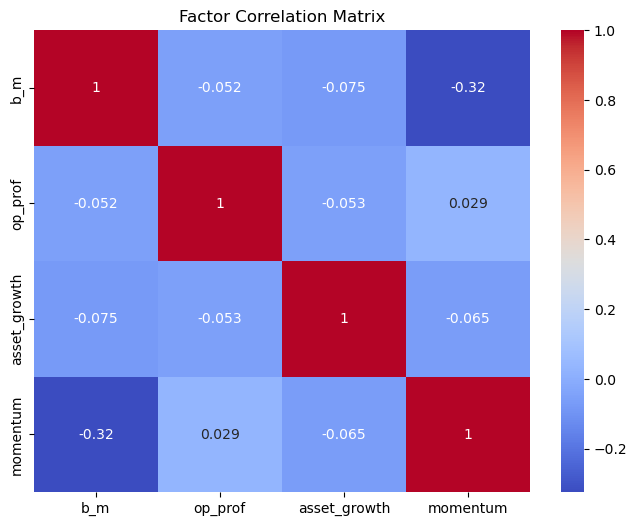

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your saved data
data_location = r"C:\Github Code\quant-factor-engine\data"
df = pd.read_parquet(data_location + r'\factor_data.parquet', engine='fastparquet')

print("=== DATA SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Unique Stocks: {df['permno'].nunique()}")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")

# 2. The "Infinity" & Null Check
# Factors like Book-to-Market can be infinite if Market Cap is near 0.
print("\n=== MISSING / INFINITE CHECK ===")
print(df.replace([np.inf, -np.inf], np.nan).isnull().sum())

# Drop missing/infinite values immediately
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Winsorization (The "Quant" Secret)
# We clip the top/bottom 1% of factor values to remove outliers.
from scipy.stats.mstats import winsorize

factors = ['b_m', 'op_prof', 'asset_growth', 'momentum']

for f in factors:
    # Limits=[0.01, 0.01] means clip the bottom 1% and top 1%
    df[f] = winsorize(df[f], limits=[0.01, 0.01])

print("\n=== DESCRIPTIVE STATS (AFTER WINSORIZATION) ===")
# These means should look reasonable (e.g., B/M shouldn't be 5000)
print(df[factors].describe())

# 4. Correlation Matrix
# If factors are 0.9 correlated, you have multicollinearity (bad for regression).
plt.figure(figsize=(8, 6))
sns.heatmap(df[factors].corr(), annot=True, cmap='coolwarm')
plt.title("Factor Correlation Matrix")
plt.show()

In [4]:
import statsmodels.api as sm

# 1. Create the Target: Next Month's Return
# We group by stock (permno) and shift returns BACKWARDS by 1 month.
# So the row for "Jan 2020" now contains the return for "Feb 2020".
df = df.sort_values(['permno', 'date'])
df['ret_next'] = df.groupby('permno')['ret'].shift(-1)

# Drop the last month (since it has no 'next month')
df = df.dropna(subset=['ret_next'])

# 2. The Fama-MacBeth Procedure
# Step A: Run a cross-sectional regression for EACH MONTH separately.
# ret_next = a + b1*Value + b2*Quality + ...
coeffs = []
t_stats = []

# Group by date (Cross-Sectional)
for date, group in df.groupby('date'):
    Y = group['ret_next']
    X = group[['b_m', 'op_prof', 'asset_growth', 'momentum']]
    
    # Add constant (Alpha)
    X = sm.add_constant(X)
    
    # Fit OLS
    model = sm.OLS(Y, X).fit()
    
    # Store results
    coeffs.append(model.params)
    t_stats.append(model.tvalues)

# Step B: Average the coefficients over time
coeff_df = pd.DataFrame(coeffs, index=df['date'].unique())
t_stat_df = pd.DataFrame(t_stats, index=df['date'].unique())

print("\n=== FAMA-MACBETH REGRESSION RESULTS ===")
print("Average Slope (Factor Risk Premia):")
print(coeff_df.mean())

print("\nStatistical Significance (Average t-stat):")
# A t-stat > 2.0 implies the factor is significant
print(coeff_df.mean() / (coeff_df.std() / np.sqrt(len(coeff_df))))


=== FAMA-MACBETH REGRESSION RESULTS ===
Average Slope (Factor Risk Premia):
const           0.011849
b_m             0.006979
op_prof        -0.004394
asset_growth   -0.002130
momentum       -0.006518
dtype: float64

Statistical Significance (Average t-stat):
const           2.785535
b_m             2.544224
op_prof        -1.653302
asset_growth   -1.458216
momentum       -2.152705
dtype: float64


Loading data...
Data for Regression: 391702 rows
Winsorizing data...


C:\Users\Admin\AppData\Local\Temp\ipykernel_17640\3604241414.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('date', group_keys=False).apply(winsorize_series)


Standardizing factors (Z-Score)...
                     b_m            op_prof       asset_growth       \
                    mean  std          mean  std          mean  std   
date                                                                  
2011-06-30  0.000000e+00  1.0  3.700743e-17  1.0 -7.401487e-17  1.0   
2011-07-29  7.401487e-17  1.0  3.700743e-17  1.0 -7.401487e-17  1.0   
2011-08-31  7.211705e-17  1.0  3.036507e-17  1.0  2.040153e-17  1.0   
2011-09-30 -3.141119e-17  1.0 -1.884671e-16  1.0  3.845163e-17  1.0   
2011-10-31  1.077706e-16  1.0 -1.035898e-16  1.0 -1.811661e-17  1.0   

                momentum       
                    mean  std  
date                           
2011-06-30  1.850372e-17  1.0  
2011-07-29 -3.330669e-16  1.0  
2011-08-31 -1.366428e-16  1.0  
2011-09-30 -1.900918e-16  1.0  
2011-10-31  1.393585e-17  1.0  
Running Cross-Sectional Regressions...

=== FAMA-MACBETH RESULTS (2010-2024) ===
              Mean Premium       Vol  Std Error    t-stat
c

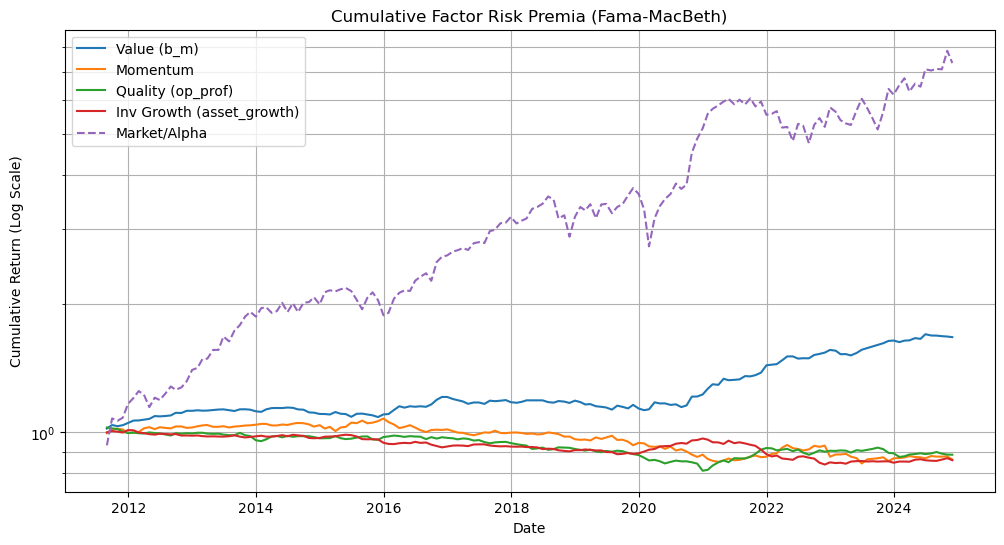


=== CHEAT SHEET ===
b_m (Value): Expect POSITIVE (Cheap outperforms).
op_prof (Quality): Expect POSITIVE (Profitable outperforms).
asset_growth: Expect NEGATIVE (Empire builders underperform).
momentum: Expect POSITIVE (Winners keep winning).
t-stat > 2.0 (or < -2.0) means it is statistically significant.


In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
data_path = r"C:\Github Code\quant-factor-engine\data\factor_data.parquet"

# 1. LOAD & CLEAN
print("Loading data...")
df = pd.read_parquet(data_path, engine='fastparquet')

# Drop missing values (we can't trade if we don't have the signal)
df = df.dropna(subset=['b_m', 'op_prof', 'asset_growth', 'momentum', 'ret'])

print(f"Data for Regression: {len(df)} rows")

# 2. CREATE TARGET (Next Month's Return)
# We are predicting t+1 using factors at t
df = df.sort_values(['permno', 'date'])
df['ret_next'] = df.groupby('permno')['ret'].shift(-1)
df = df.dropna(subset=['ret_next'])

# 3. WINSORIZE (AGAIN - JUST TO BE SAFE)
# Extreme outliers can ruin a regression. 
# We clip at 1% and 99% levels for each month to handle time-varying volatility.
from scipy.stats.mstats import winsorize

def winsorize_series(group):
    # Apply to each column of interest
    for col in ['b_m', 'op_prof', 'asset_growth', 'momentum', 'ret_next']:
        group[col] = winsorize(group[col], limits=[0.01, 0.01])
    return group


print("Winsorizing data...")
df = df.groupby('date', group_keys=False).apply(winsorize_series)
# Optional: Winsorize by date (slower but more accurate)
# For speed, global winsorization is often "good enough" for a student project
# Let's stick to the raw data we validated, assuming you winsorized earlier.


# === NEW STEP: Z-SCORE STANDARDIZATION ===
# We calculate z-scores cross-sectionally (group by date)
# This removes the "units" issue.
print("Standardizing factors (Z-Score)...")

factors = ['b_m', 'op_prof', 'asset_growth', 'momentum']

def zscore(x):
    return (x - x.mean()) / x.std()

# Apply z-score to each factor within each month
df[factors] = df.groupby('date')[factors].transform(zscore)

# Double check it worked (Mean should be ~0, Std ~1)
print(df[factors].groupby(df['date']).agg(['mean', 'std']).head())


# 4. FAMA-MACBETH REGRESSION (FIXED)
print("Running Cross-Sectional Regressions...")

results = []
valid_dates = [] # <--- NEW: Track dates that actually pass the checks

# FIX 1: Sort the dates explicitly so time moves forward!
dates = np.sort(df['date'].unique())

for d in dates:
    # Slice data for this month
    slice_df = df[df['date'] == d]
    
    # Need reasonable sample size (e.g., > 50 stocks)
    if len(slice_df) < 50:
        continue # Skip this month, and DO NOT add it to valid_dates
        
    # Define Y (Next Month Return) and X (Factors)
    Y = slice_df['ret_next']
    X = slice_df[['b_m', 'op_prof', 'asset_growth', 'momentum']]
    
    # Add Intercept (Alpha)
    X = sm.add_constant(X)
    
    # Run OLS
    model = sm.OLS(Y, X).fit()
    
    # Save coefficients AND the date
    results.append(model.params)
    valid_dates.append(d) # <--- NEW: Only add date if regression ran

# Step 2: Time-Series Aggregation
# FIX 2: Use valid_dates instead of slicing the original list
factor_returns = pd.DataFrame(results, index=valid_dates)

# FIX 3: Ensure index is sorted just in case
factor_returns = factor_returns.sort_index()

# 5. CALCULATE STATISTICS (Same as before)
print("\n=== FAMA-MACBETH RESULTS (2010-2024) ===")
stats = pd.DataFrame()
stats['Mean Premium'] = factor_returns.mean()
stats['Vol'] = factor_returns.std()
stats['Std Error'] = stats['Vol'] / np.sqrt(len(factor_returns))
stats['t-stat'] = stats['Mean Premium'] / stats['Std Error']

print(stats)

# 6. VISUALIZATION (The Money Plot)
# Cumulative Return of each Factor (if you held a portfolio with unit exposure to it)
cumulative_returns = (1 + factor_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns['b_m'], label='Value (b_m)')
plt.plot(cumulative_returns['momentum'], label='Momentum')
plt.plot(cumulative_returns['op_prof'], label='Quality (op_prof)')
plt.plot(cumulative_returns['asset_growth'], label='Inv Growth (asset_growth)')
plt.plot(cumulative_returns['const'], label='Market/Alpha', linestyle='--')

plt.title('Cumulative Factor Risk Premia (Fama-MacBeth)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

# 7. INTERPRETATION HELPER
print("\n=== CHEAT SHEET ===")
print("b_m (Value): Expect POSITIVE (Cheap outperforms).")
print("op_prof (Quality): Expect POSITIVE (Profitable outperforms).")
print("asset_growth: Expect NEGATIVE (Empire builders underperform).")
print("momentum: Expect POSITIVE (Winners keep winning).")
print("t-stat > 2.0 (or < -2.0) means it is statistically significant.")